In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Imports
import os
import cv2
import sys
import glob
import time
import json
import copy
import cortex
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.spatial import Delaunay

# Personal imports
sys.path.append("{}/../../analysis_code/utils".format(os.getcwd()))
# from plot_utils import *
from settings_utils import load_settings
from pycortex_utils import  set_pycortex_config_file, load_surface_pycortex, create_colormap, get_rois ,draw_cortex
from surface_utils import load_surface

In [2]:
def draw_cortex(subject, data, vmin, vmax, description, cortex_type='VolumeRGB', cmap='Viridis',
                cbar='discrete', cmap_dict=None, cmap_steps=255, xfmname=None,
                alpha=None, depth=1, thick=1, height=1024, sampler='nearest',
                with_curvature=True, with_labels=False, with_colorbar=False,
                with_borders=False, curv_brightness=0.95, curv_contrast=0.05, add_roi=False,
                roi_name='empty', col_offset=0, zoom_roi=None, zoom_hem=None, zoom_margin=0.0,
                cbar_label='', overlay_fn='None', roi_list=None, return_webgl=False):
    """
    Plot brain data onto a previously saved flatmap.

    Parameters
    ----------
    subject             : subject id (e.g. 'sub-001')
    xfmname             : xfm transform
    data                : the data you would like to plot on a flatmap
    cmap                : colormap that should be used for plotting
    cmap_dict           : colormap dict of label and color for personalized colormap
    vmin                : minimal value of colormap (list [1D, 2D] for Volume2D)
    vmax                : maximal value of colormap (list [1D, 2D] for Volume2D)
    description         : plot title
    cortex_type         : cortex function to create the volume (VolumeRGB, Volume2D, VertexRGB, Vertex)
    cbar                : color bar layout
    cbar_label          : colorbar label
    cmap_steps          : number of colormap bins
    alpha               : alpha map, values between 0 and 1 (NaN = transparent)
    depth               : Value between 0 and 1 for how deep to sample the surface for the flatmap
    thick               : Number of layers through the cortical sheet to sample
    height              : Height of the image to render
    sampler             : 'trilinear', 'nearest', 'lanczos'
    with_curvature      : Display curvature?
    with_labels         : Display labels?
    with_colorbar       : Display pycortex colorbar?
    with_borders        : Display borders?
    curv_brightness     : Mean brightness of background (0 = black, 1 = white)
    curv_contrast       : Contrast of curvature (0 = none, 1 = max)
    add_roi             : add roi -image- to overlay.svg
    roi_name            : roi name
    col_offset          : colormap offset between 0 and 1
    zoom_roi            : name of the roi on which to zoom on
    zoom_hem            : hemifield of the roi zoom
    zoom_margin         : margin in mm around the zoom
    overlay_fn          : file name of the overlay file (e.g. 'overlay_rois-drawn.svg')
    roi_list            : List of rois borders to plot (e.g. ['V1', 'V2'])
    return_webgl        : if True, also return a version of the data for cortex.webgl.show
                          (for VertexRGB: not blended with curvature, keeps its alpha channel)

    Returns
    -------
    braindata                    : pycortex volume or vertex object (used for the flatmap)
    (braindata, braindata_webgl) : if return_webgl=True
    """

    import cortex
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import matplotlib.colors as colors

    # ------------------------------------------------------------------
    # Colormap
    # ------------------------------------------------------------------
    try:
        base = mpl.colormaps[cmap]
    except (KeyError, ValueError):
        base = cortex.utils.get_cmap(cmap)

    if '_alpha' in cmap:
        base.colors = base.colors[1, :, :]
    val = np.linspace(0, 1, cmap_steps, endpoint=False)
    colmap = colors.LinearSegmentedColormap.from_list('my_colmap', base(val), N=cmap_steps)

    # ------------------------------------------------------------------
    # Overlay file
    # ------------------------------------------------------------------
    if overlay_fn in (None, 'None'):
        overlay_file = None
    else:
        db_path = cortex.database.default_filestore
        overlay_file = f"{db_path}/{subject}/{overlay_fn}"

    # ------------------------------------------------------------------
    # Helpers: data -> RGB (uint8) and alpha (0-1, no NaN)
    # ------------------------------------------------------------------
    def _data_to_rgb(d):
        d = np.asarray(d, dtype=float)
        vrange = float(vmax) - float(vmin)
        idx = (d - float(vmin)) / vrange * cmap_steps
        idx = np.nan_to_num(idx, nan=0.0, posinf=cmap_steps - 1, neginf=0.0)
        idx = np.clip(idx, 0, cmap_steps - 1).astype(int)
        return (colmap(idx)[..., :3] * 255.0).astype(np.uint8)

    def _clean_alpha(a, shape):
        if a is None:
            return np.ones(shape, dtype=float)
        a = np.nan_to_num(np.asarray(a, dtype=float), nan=0.0)
        a = np.clip(a, 0, 1)
        # NaN in data -> transparent
        a[np.isnan(np.asarray(data, dtype=float))] = 0.0
        return a

    braindata_webgl = None

    # ------------------------------------------------------------------
    # Build pycortex object
    # ------------------------------------------------------------------
    if cortex_type == 'VolumeRGB':
        rgb = _data_to_rgb(data)
        alpha01 = _clean_alpha(alpha, np.shape(data))
        braindata = cortex.VolumeRGB(channel1=rgb[..., 0].T,
                                     channel2=rgb[..., 1].T,
                                     channel3=rgb[..., 2].T,
                                     alpha=(alpha01 * 255).astype(np.uint8).T,
                                     subject=subject,
                                     xfmname=xfmname)
        braindata_webgl = braindata

    elif cortex_type == 'Volume2D':
        braindata = cortex.Volume2D(dim1=data.T,
                                    dim2=alpha.T,
                                    subject=subject,
                                    xfmname=xfmname,
                                    description=description,
                                    cmap=cmap,
                                    vmin=vmin[0], vmax=vmax[0],
                                    vmin2=vmin[1], vmax2=vmax[1])
        braindata_webgl = braindata

    elif cortex_type == 'VertexRGB':
        rgb = _data_to_rgb(data)
        alpha01 = _clean_alpha(alpha, np.shape(data))

        # Unblended version: keeps its alpha channel -> transparency in WebGL
        braindata_webgl = cortex.VertexRGB(red=rgb[..., 0],
                                           green=rgb[..., 1],
                                           blue=rgb[..., 2],
                                           alpha=(alpha01 * 255).astype(np.uint8),
                                           subject=subject)

        # Flatmap version: curvature blended into the colors (alpha must be 0-1)
        braindata = braindata_webgl.blend_curvature(alpha01,
                                                    brightness=curv_brightness,
                                                    contrast=curv_contrast)

    elif cortex_type == 'Vertex':
        braindata = cortex.Vertex(data=data,
                                  subject=subject,
                                  description=description,
                                  cmap=cmap,
                                  vmin=vmin,
                                  vmax=vmax)
        braindata_webgl = braindata

    else:
        raise ValueError(f"Unknown cortex_type: {cortex_type}")

    # ------------------------------------------------------------------
    # Flatmap
    # ------------------------------------------------------------------
    braindata_fig = cortex.quickshow(braindata=braindata,
                                     depth=depth,
                                     thick=thick,
                                     height=height,
                                     sampler=sampler,
                                     with_curvature=with_curvature,
                                     nanmean=True,
                                     overlay_file=overlay_file,
                                     with_labels=with_labels,
                                     with_colorbar=with_colorbar,
                                     with_borders=with_borders,
                                     curvature_brightness=curv_brightness,
                                     curvature_contrast=curv_contrast,
                                     roi_list=roi_list)

    # ------------------------------------------------------------------
    # Colorbars
    # ------------------------------------------------------------------
    if cbar == 'polar':
        cbar_axis = braindata_fig.add_axes([0.5, 0.07, 0.8, 0.2], projection='polar')
        norm = colors.Normalize(0, 2 * np.pi)
        t = np.linspace(0, 2 * np.pi, 200, endpoint=True)
        r = [0, 1]
        rg, tg = np.meshgrid(r, t)
        cbar_axis.pcolormesh(t, r, tg.T, norm=norm, cmap=colmap)
        cbar_axis.set_yticklabels([])
        cbar_axis.set_xticklabels([])
        cbar_axis.set_theta_zero_location("W")
        cbar_axis.spines['polar'].set_visible(False)

    elif cbar == 'ecc':
        colorbar_location = [0.5, 0.07, 0.8, 0.2]
        n = 200
        cbar_axis = braindata_fig.add_axes(colorbar_location, projection='polar')
        t = np.linspace(0, 2 * np.pi, n)
        r = np.linspace(0, 1, n)
        rg, tg = np.meshgrid(r, t)
        cbar_axis.pcolormesh(t, r, tg, norm=mpl.colors.Normalize(0, 2 * np.pi), cmap=colmap)
        cbar_axis.tick_params(pad=1, labelsize=15)
        cbar_axis.spines['polar'].set_visible(False)
        box = cbar_axis.get_position()
        cbar_axis.set_yticklabels([])
        cbar_axis.set_xticklabels([])
        axl = braindata_fig.add_axes([0.97 * box.xmin, 0.5 * (box.ymin + box.ymax),
                                      box.width / 600, box.height * 0.5])
        axl.spines['top'].set_visible(False)
        axl.spines['right'].set_visible(False)
        axl.spines['bottom'].set_visible(False)
        axl.yaxis.set_ticks_position('right')
        axl.xaxis.set_ticks_position('none')
        axl.set_xticklabels([])
        axl.set_yticks(np.linspace(0, 1, 3))
        axl.set_yticklabels(np.linspace(vmin, vmax, 3), size='x-large')
        axl.set_ylabel('$dva$\t\t', rotation=0, size='x-large')
        axl.yaxis.set_label_coords(box.xmax + 30, 0.4)
        axl.patch.set_alpha(0.5)

    elif cbar == 'discrete':
        colorbar_location = [0.8, 0.05, 0.1, 0.05]
        bounds = np.linspace(vmin, vmax, cmap_steps + 1)
        bounds_label = np.linspace(vmin, vmax, 3)
        norm = mpl.colors.BoundaryNorm(bounds, colmap.N)
        cbar_axis = braindata_fig.add_axes(colorbar_location)
        cb = mpl.colorbar.ColorbarBase(cbar_axis, cmap=colmap, norm=norm, ticks=bounds_label,
                                       boundaries=bounds, orientation='horizontal')
        cb.set_label(cbar_label, size='x-large')

    elif cbar == '2D':
        cbar_axis = braindata_fig.add_axes([0.8, 0.05, 0.15, 0.15])
        base2d = cortex.utils.get_cmap(cmap)
        cbar_axis.imshow(np.dstack((base2d.colors[..., 0], base2d.colors[..., 1],
                                    base2d.colors[..., 2], base2d.colors[..., 3])))
        cbar_axis.set_xticks(np.linspace(0, 255, 3))
        cbar_axis.set_yticks(np.linspace(0, 255, 3))
        cbar_axis.set_xticklabels(np.linspace(vmin[0], vmax[0], 3))
        cbar_axis.set_yticklabels(np.linspace(vmax[1], vmin[1], 3))
        cbar_axis.set_xlabel(cbar_label[0], size='x-large')
        cbar_axis.set_ylabel(cbar_label[1], size='x-large')

    elif cbar == 'discrete_personalized':
        colorbar_location = [0.05, 0.02, 0.04, 0.3]
        cbar_axis = braindata_fig.add_axes(colorbar_location)
        norm = mpl.colors.BoundaryNorm(np.linspace(0, len(cmap_dict), len(cmap_dict) + 1),
                                       len(cmap_dict))
        cb = mpl.colorbar.ColorbarBase(cbar_axis,
                                       cmap=base.reversed(),
                                       norm=norm,
                                       ticks=(np.arange(0, len(cmap_dict), 1) + 0.5),
                                       orientation='vertical')
        cb.set_ticklabels(list(reversed(cmap_dict.keys())))
        cb.ax.tick_params(size=0, labelsize=15)

    elif cbar == 'glm':
        val = np.linspace(0, 1, cmap_steps + 1, endpoint=False)
        val = val[val > 0.25]  # exclude near-white values
        colmapglm = colors.LinearSegmentedColormap.from_list('my_colmap', base(val), N=len(val))
        colorbar_location = [0.85, 0.02, 0.04, 0.2]
        bounds_label = ['Both', 'Saccade', 'Pursuit']
        bounds = np.linspace(vmin, vmax, colmap.N)
        ticks_positions = [0.5, 1.5, 2.5]
        norm = mpl.colors.BoundaryNorm(bounds, colmap.N)
        cbar_axis = braindata_fig.add_axes(colorbar_location)
        cb = mpl.colorbar.ColorbarBase(cbar_axis, cmap=colmapglm.reversed(), norm=norm,
                                       ticks=ticks_positions, orientation='vertical')
        cb.set_ticklabels(bounds_label)
        cb.ax.tick_params(size=0, labelsize=20)

    elif cbar == 'stats':
        val = np.linspace(0, 1, cmap_steps + 1, endpoint=False)
        val = val[val > 0.13]
        colmapglm = colors.LinearSegmentedColormap.from_list('my_colmap', base(val), N=len(val))
        colorbar_location = [0.05, 0.02, 0.04, 0.2]
        bounds_label = ['pursuit', 'saccade', 'pursuit_and_saccade', 'vision',
                        'vision_and_pursuit', 'vision_and_saccade',
                        'vision_and_saccade_and_pursuite']
        bounds = np.linspace(vmin, vmax, colmap.N)
        ticks_positions = [6.5, 5.5, 4.5, 3.5, 2.5, 1.5, 0.5]
        norm = mpl.colors.BoundaryNorm(bounds, colmap.N)
        cbar_axis = braindata_fig.add_axes(colorbar_location)
        cb = mpl.colorbar.ColorbarBase(cbar_axis, cmap=colmapglm.reversed(), norm=norm,
                                       ticks=ticks_positions, orientation='vertical')
        cb.set_ticklabels(bounds_label)
        cb.ax.tick_params(size=0, labelsize=20)

    # ------------------------------------------------------------------
    # Add to overlay
    # ------------------------------------------------------------------
    if add_roi:
        cortex.utils.add_roi(data=braindata,
                             name=roi_name,
                             open_inkscape=False,
                             add_path=False,
                             depth=depth,
                             thick=thick,
                             sampler=sampler,
                             with_curvature=with_curvature,
                             with_colorbar=with_colorbar,
                             with_borders=with_borders,
                             curvature_brightness=curv_brightness,
                             curvature_contrast=curv_contrast)

    if return_webgl:
        return braindata, braindata_webgl
    return braindata

In [2]:
# Directories
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'amblyo7T_prf'

In [3]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")

settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]

preproc_prep = analysis_info['preproc_prep']
filtering = analysis_info['filtering']
normalization = analysis_info['normalization']
subjects = analysis_info['subjects']


In [4]:
# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)

# Webgl port
port_num = 25000

In [5]:
# Settings
subject = 'sub-16'
pycortex_subject = 'sub-16'
format_ = 'fsnative'
extension = 'func.gii'
rsq2use = 'prf_loo_rsq'
avg_method = 'loo-avg'
save_svg = False

rois_method_format = 'rois-group-mmp'
overlay_fn = "overlays_{}.svg".format('rois-group-mmp' )

# /Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/pp_data/cortex/db/sub-02/overlays_rois-group-mmp.svg

In [6]:
cortex_dir

'/Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/pp_data/cortex'

In [7]:
maps_names_css = analysis_info['maps_names_gauss']
for idx, col_name in enumerate(maps_names_css ):
    exec("{}_idx = idx".format(col_name))

# Subject

## flatmaps

In [8]:
prf_derif_dir = '{}/{}/derivatives/pp_data/{}/{}/prf/prf_derivatives'.format(main_dir, project_dir, subject, format_)

LE_LH_deriv_fn = '{}/{}_task-BarsBarsRingsWedgesLeftEye_hemi-L_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'.format(prf_derif_dir, subject)
LE_RH_deriv_fn = '{}/{}_task-BarsBarsRingsWedgesLeftEye_hemi-R_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'.format(prf_derif_dir, subject)

# Laod data
LE_deriv_mat = load_surface_pycortex(L_fn=LE_LH_deriv_fn, R_fn=LE_RH_deriv_fn)['data_concat']


RE_LH_deriv_fn = '{}/{}_task-BarsBarsRingsWedgesRightEye_hemi-L_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'.format(prf_derif_dir, subject)
RE_RH_deriv_fn = '{}/{}_task-BarsBarsRingsWedgesRightEye_hemi-R_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'.format(prf_derif_dir, subject)

# Laod data
RE_deriv_mat = load_surface_pycortex(L_fn=RE_LH_deriv_fn, R_fn=RE_RH_deriv_fn)['data_concat']


In [9]:
LE_prf_amp = LE_deriv_mat[amplitude_idx, :]
RE_prf_amp = RE_deriv_mat[amplitude_idx, :]

LE_prf_rsq = LE_deriv_mat[prf_rsq_idx, :]
RE_prf_rsq = RE_deriv_mat[prf_rsq_idx, :]



# Compute OD 
# OD = ((LE_prf_amp * LE_prf_rsq) - (RE_prf_amp * RE_prf_rsq))/((LE_prf_amp * LE_prf_rsq) + (RE_prf_amp * RE_prf_rsq))
OD = (LE_prf_amp - RE_prf_amp)/(LE_prf_amp  + RE_prf_amp )

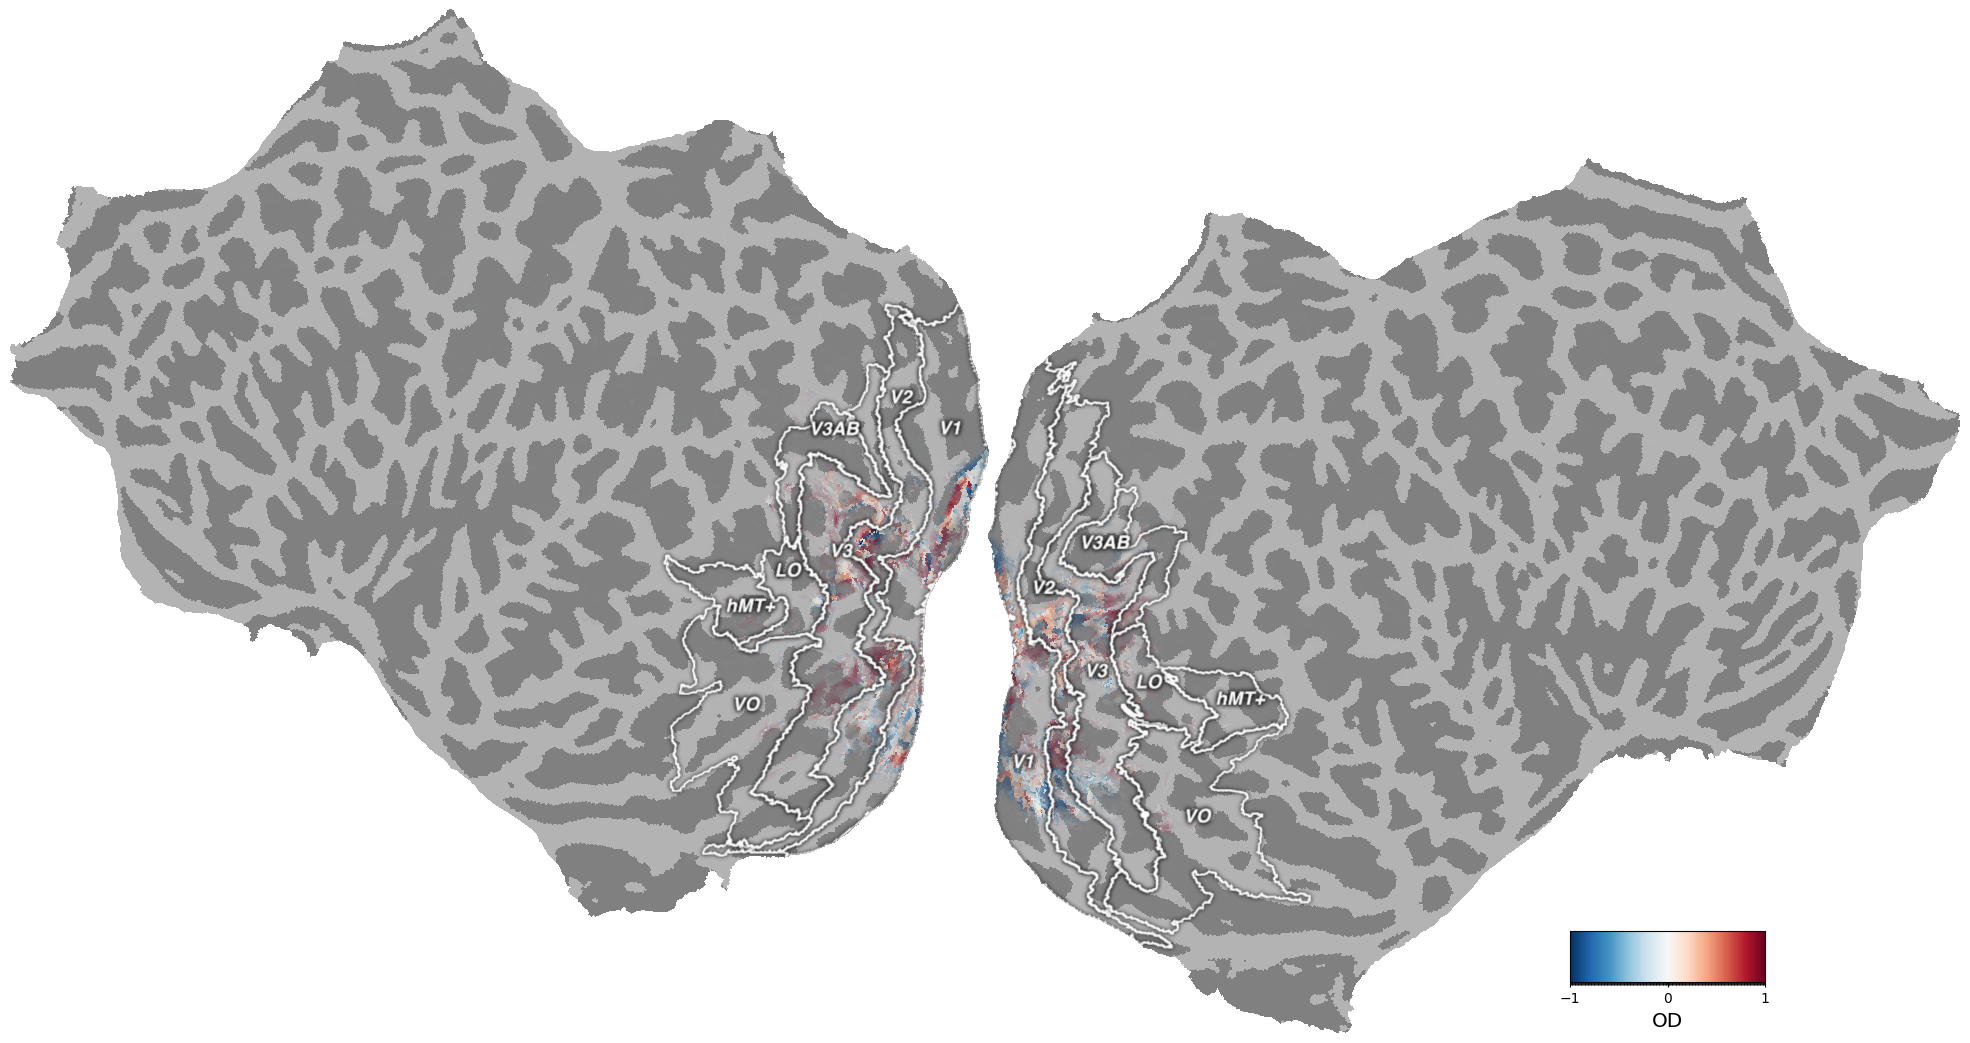

In [10]:
vmin= -1
vmax= 1
cmap = 'RdBu_r'
alpha_range = analysis_info["flatmap_alpha_range"]

alpha = np.nanmean(np.array([LE_prf_rsq, RE_prf_rsq]), axis=0)
alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
alpha[alpha>1] = 1
# alpha = np.zeros_like(OD)

param_OD = {'data': OD,
            'subject':subject,
             'cmap': cmap,
             'alpha': alpha,
             'vmin': vmin,
             'vmax': vmax,
             'cbar': 'discrete',
             'cortex_type': 'VertexRGB',
             'description': 'OD',
             'curv_brightness': 0.6,
             'curv_contrast': 0.2,
             'add_roi': False,
             'cbar_label': 'OD',
             'overlay_fn': overlay_fn,
             'with_labels': True}
volume_bold = draw_cortex(**param_OD)
plt.savefig('/Users/uriel/Downloads/{}_OD.pdf'.format(subject))

In [11]:
alpha_range

[0, 0.4]

In [12]:
# Remome overlays_visible=('sulci','roi'), to have borders 
port_num = port_num + 1
print("Go to (in 5 s...): http://localhost:{}/".format(port_num))
handle = cortex.webgl.show(data=volume_bold,
                           recache=True,
                           port=port_num,
                           overlays_visible=('rois',),
                           labels_visible=(),
                           overlay_file = '{}/db/{}/{}'.format(cortex_dir,subject, overlay_fn),
                          )

Go to (in 5 s...): http://localhost:25001/
Generating new ctm file...
wm
wm
inflated
inflated
Started server on port 25001


In [14]:
overlay_fn

'overlays_rois-group-mmp.svg'

### fig

In [15]:
rois_dict = get_rois(subject=pycortex_subject, 
                          surf_format='fsnative', 
                          rois_type='rois-mmp', 
                          mask=True, 
                          rois=None, 
                          hemis=None)
rois_to_keep = ['V1', 'V2', 'V3', 'V4', 'V3A', 'V3B', 'LO1', 'LO2']

rois_dict = {roi: rois_dict[roi] for roi in rois_to_keep if roi in rois_dict}

missing = set(rois_to_keep) - set(rois_dict)
if missing:
    print(f'ROI absentes de rois_dict : {missing}')

In [16]:
rows = []
for roi, mask in rois_dict.items():
    od_roi = OD[mask]
    od_roi = od_roi[np.isfinite(od_roi)]  # retire NaN/inf (voxels exclus, dénominateur nul)
    n = od_roi.size

    rows.append({
        'roi': roi,
        'n_vertices': n,
        'percent_left': 100 * np.sum(od_roi > 0) / n if n else np.nan,
        'percent_right': 100 * np.sum(od_roi < 0) / n if n else np.nan,
        'median_OD': np.median(od_roi) if n else np.nan,
    })

od_roi_df = pd.DataFrame(rows).set_index('roi')


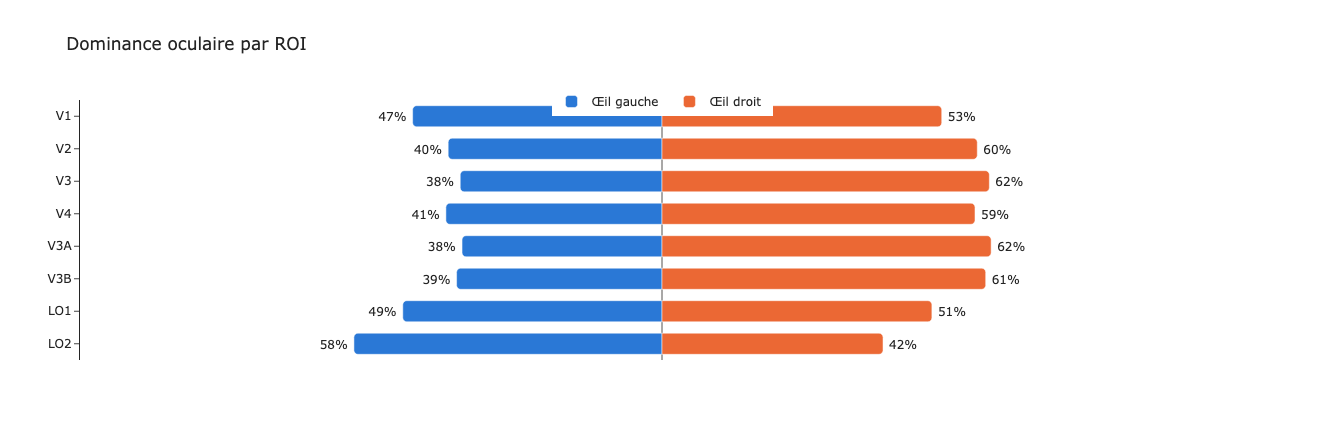

In [13]:
import numpy as np
import plotly.graph_objects as go

df = od_roi_df.copy()
rois = df.index.tolist()

left = df['percent_left'].values
right = df['percent_right'].values

fig = go.Figure()

# Œil gauche : valeurs négatives pour partir vers la gauche
fig.add_trace(go.Bar(
    y=rois, x=-left, orientation='h',
    name='Œil gauche',
    marker=dict(color='#2a78d6'),
    text=[f'{v:.0f}%' for v in left], textposition='outside',
    customdata=np.stack([left, df['n_vertices']], axis=-1),
    hovertemplate='%{y}<br>Œil gauche : %{customdata[0]:.1f}%'
                  '<br>n = %{customdata[1]}<extra></extra>',
))

# Œil droit
fig.add_trace(go.Bar(
    y=rois, x=right, orientation='h',
    name='Œil droit',
    marker=dict(color='#eb6834'),
    text=[f'{v:.0f}%' for v in right], textposition='outside',
    customdata=np.stack([right, df['n_vertices']], axis=-1),
    hovertemplate='%{y}<br>Œil droit : %{customdata[0]:.1f}%'
                  '<br>n = %{customdata[1]}<extra></extra>',
))

# Graduations symétriques affichées en valeurs absolues
ticks = np.arange(-100, 101, 25)
fig.update_xaxes(
    range=[-110, 110],
    showticklabels=False,
    ticks='',
    showgrid=False,
    showline=False,
    title=None,
    zeroline=True, zerolinecolor='#52514e', zerolinewidth=1,
)
fig.update_yaxes(autorange='reversed')  # 1re ROI en haut

fig.update_layout(
    barmode='relative',
    bargap=0.35,
    barcornerradius=4,          # plotly >= 5.19, sinon retire cette ligne
    template='simple_white',
    height=80 + 45 * len(rois),
    legend=dict(orientation='h', x=0.5, xanchor='center', y=1.05),
    title='Dominance oculaire par ROI',
)

fig.show()
fig.write_image('/Users/uriel/Downloads/{}_fig_OD.pdf'.format(subject))

# group plot

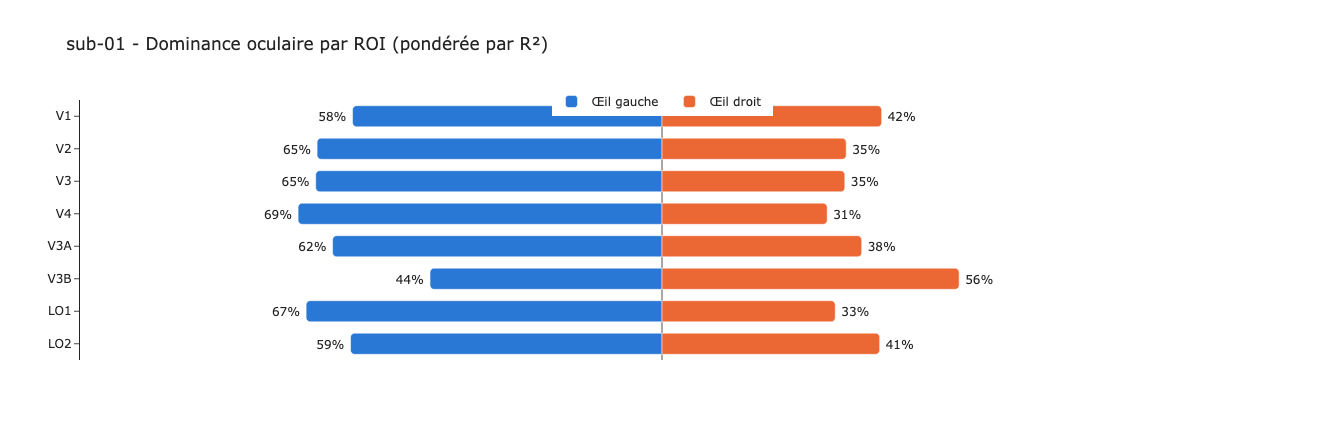

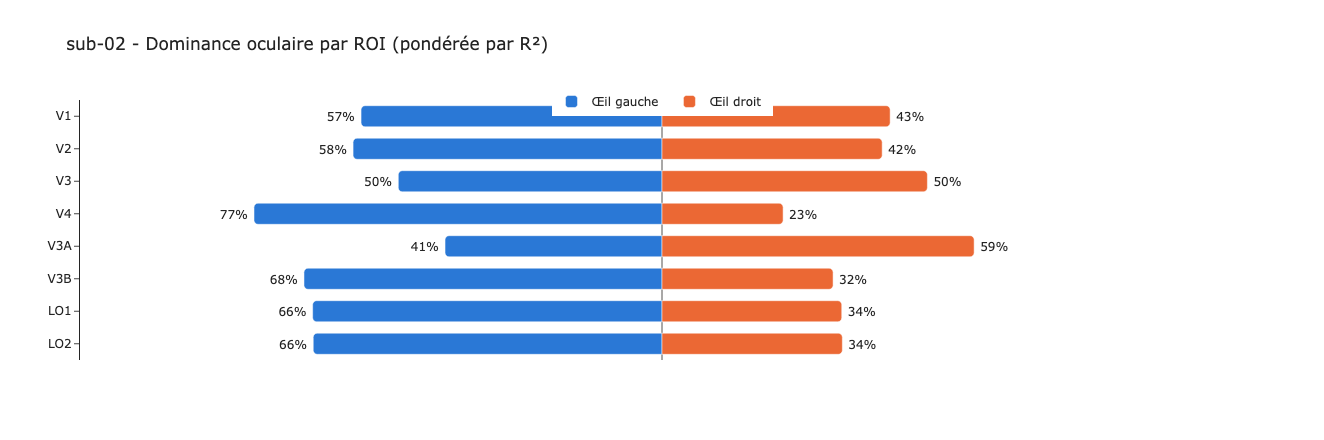

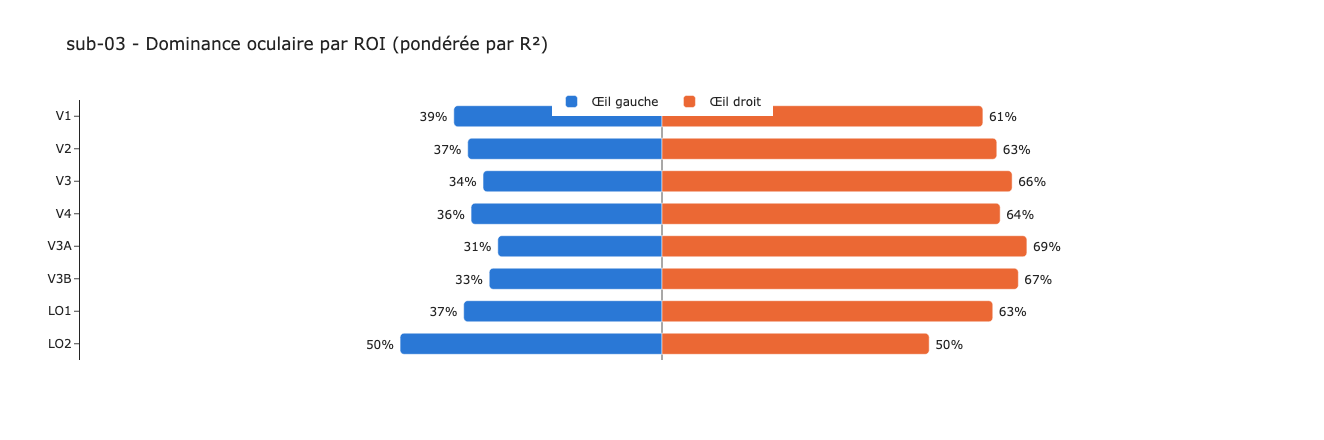

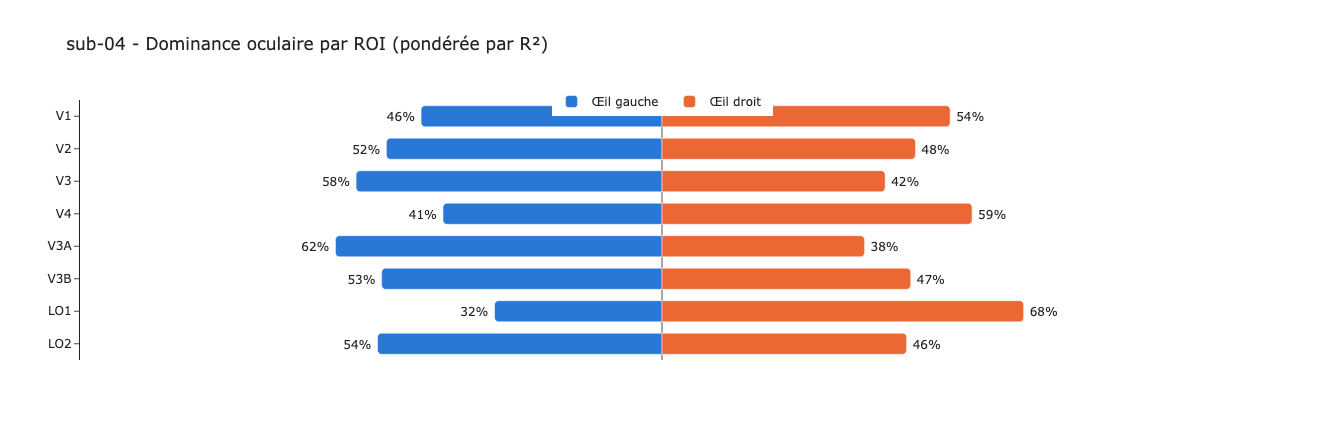

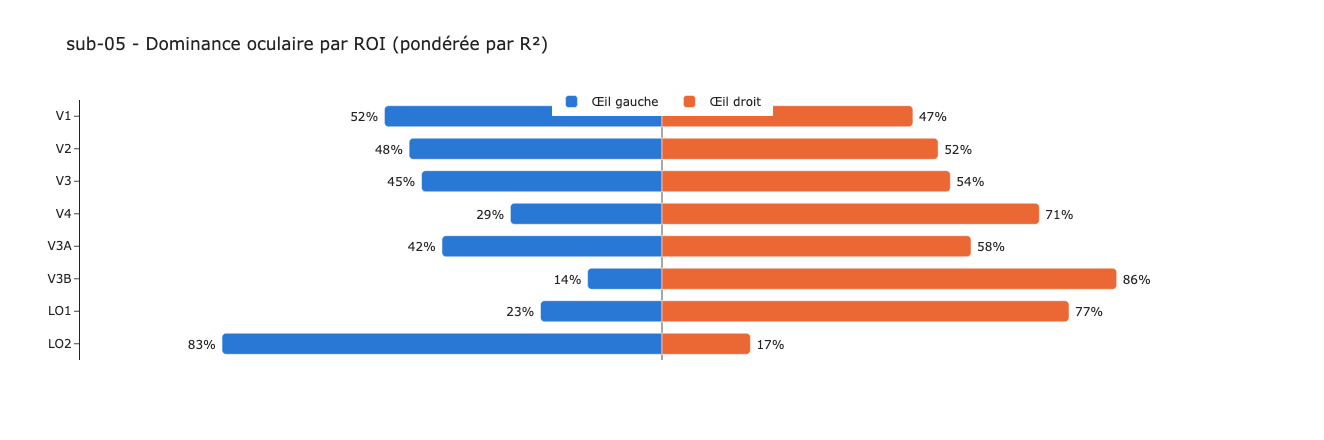

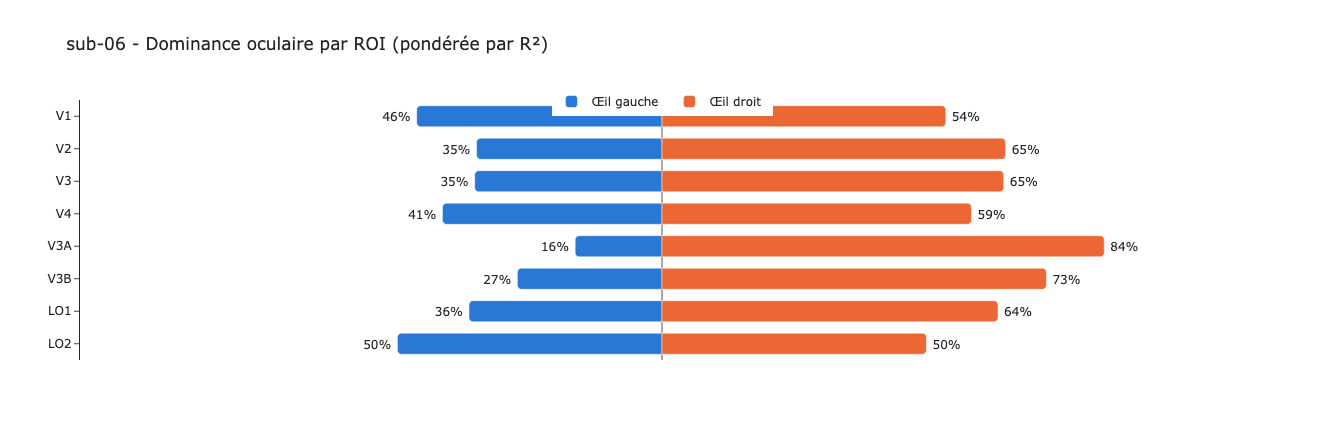

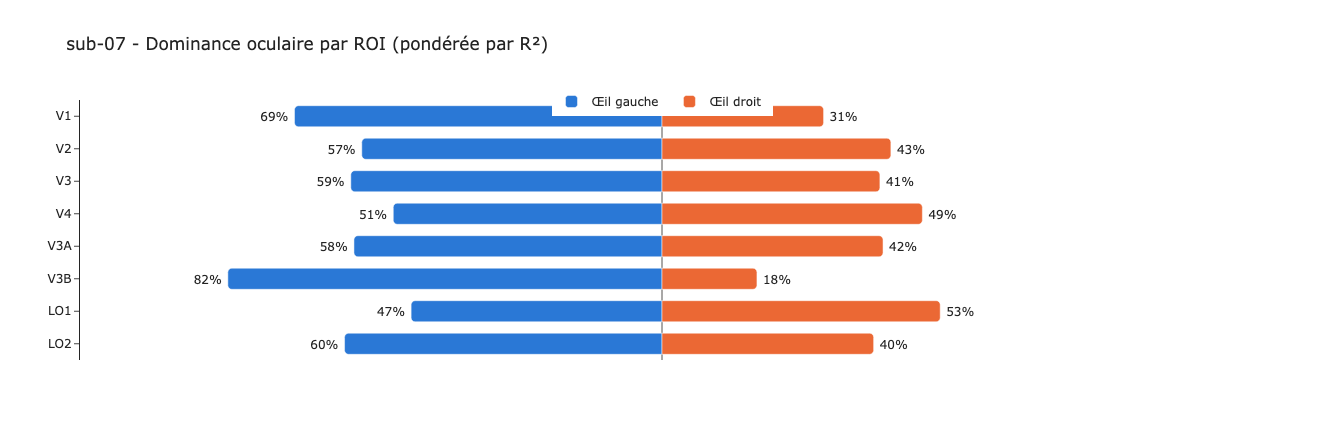

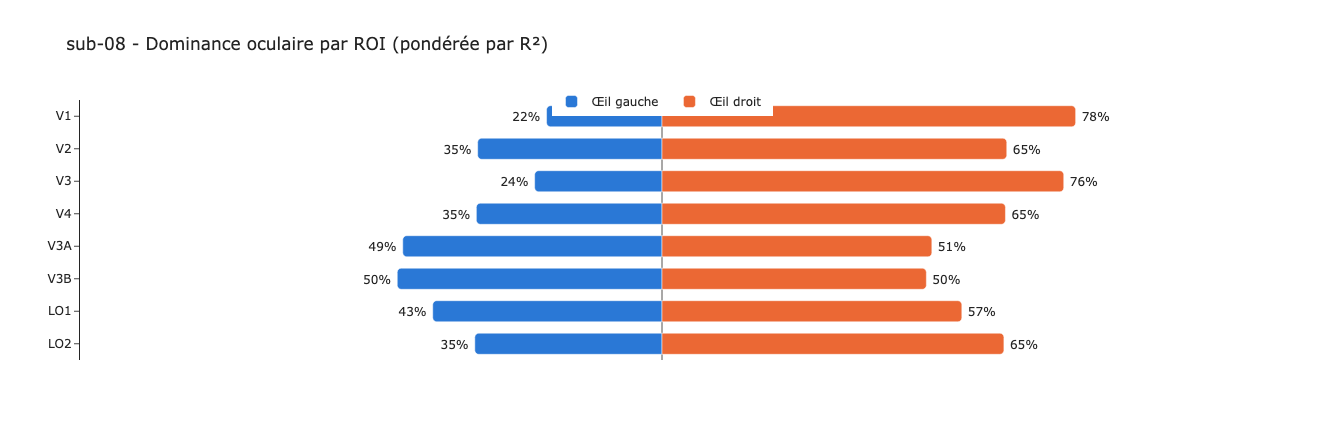

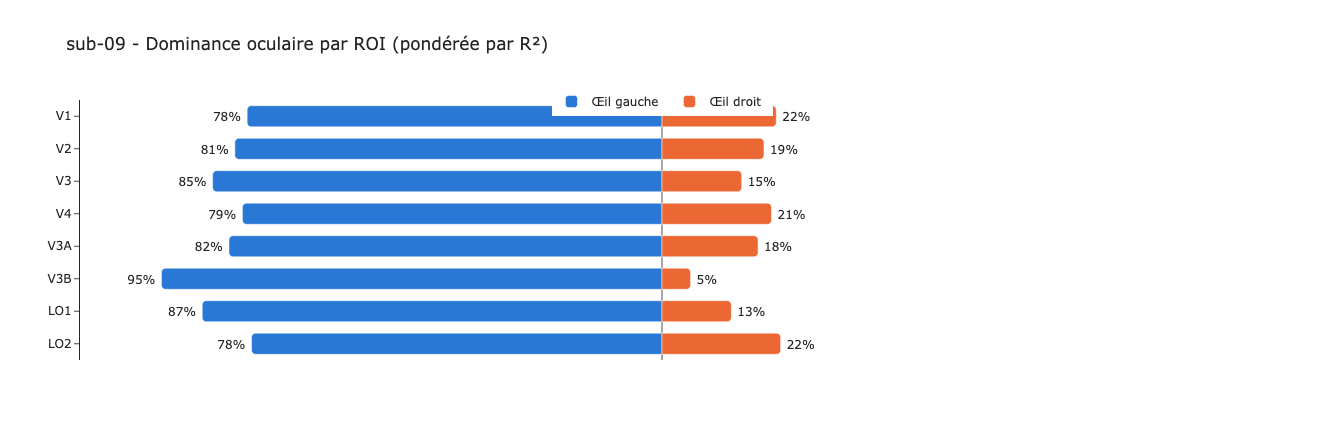

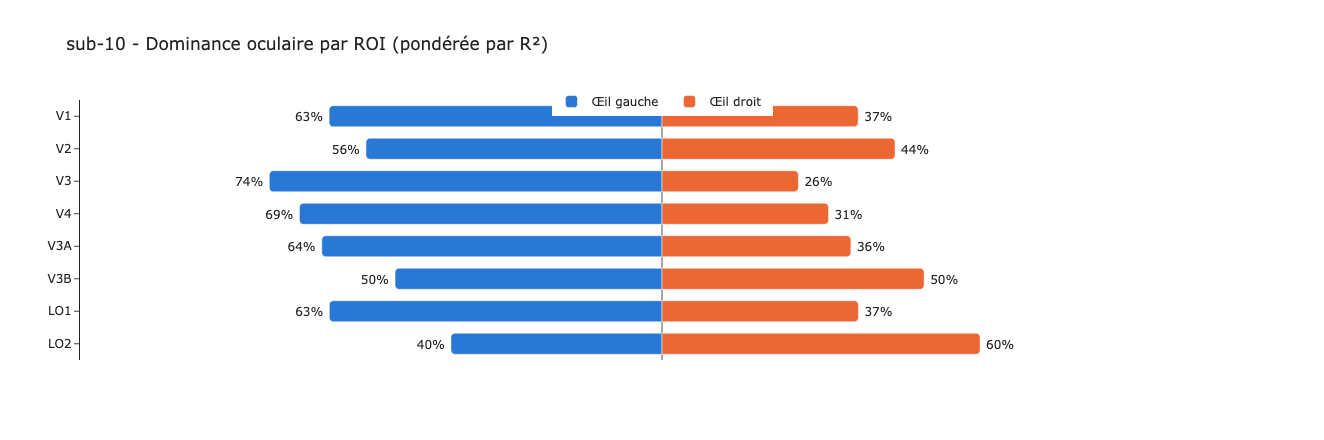

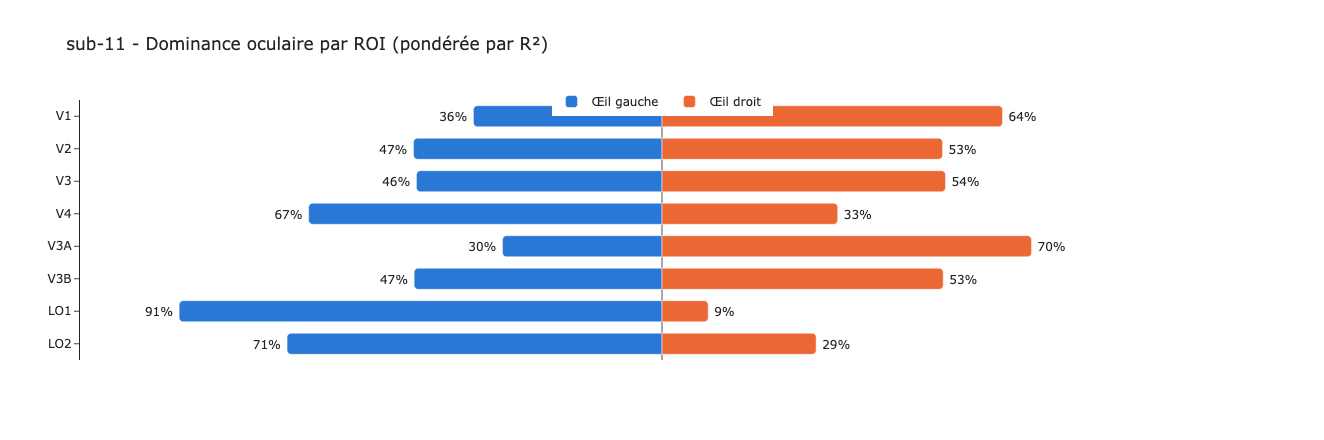

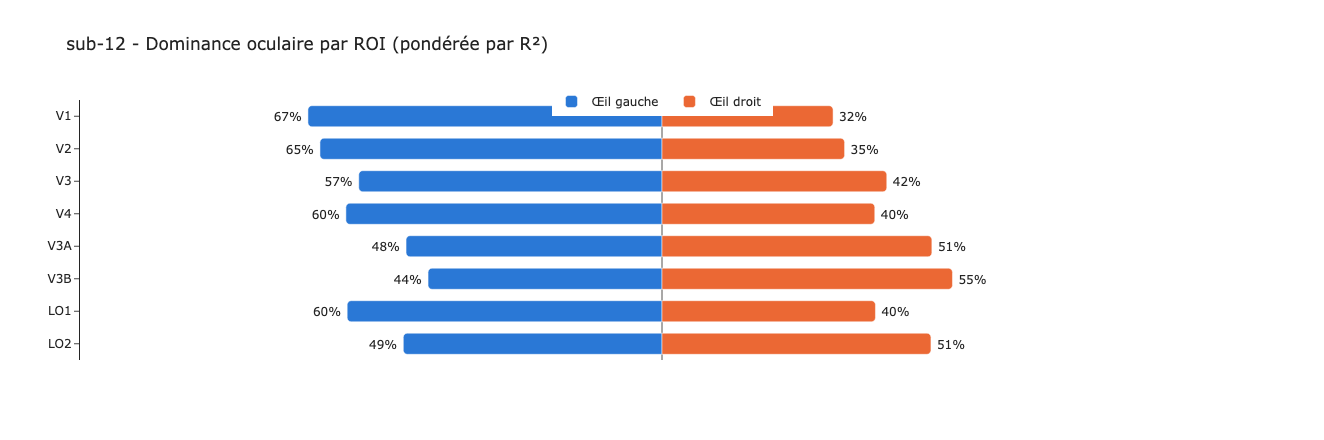

FileNotFoundError: No such file or no access: '/Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/pp_data/sub-13/fsnative/prf/prf_derivatives/sub-13_task-BarsBarsRingsWedgesLeftEye_hemi-L_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'

In [9]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def threshold_mask(deriv_mat, analysis_info):
    """Masque booléen des vertex qui passent tous les seuils."""
    amp = deriv_mat[amplitude_idx, :]
    rsq = deriv_mat[prf_rsq_idx, :]
    size = deriv_mat[prf_size_idx, :]
    ecc = deriv_mat[prf_ecc_idx, :]
    # n = deriv_mat[prf_n_idx, :]

    # if analysis_info['stats_th'] == 0.05:
    #     stats_ok = deriv_mat[corr_pvalue_5pt_idx, :] <= 0.05
    # elif analysis_info['stats_th'] == 0.01:
    #     stats_ok = deriv_mat[corr_pvalue_1pt_idx, :] <= 0.01

    return np.logical_and.reduce((
        amp > 0,
        rsq >= analysis_info['rsqr_th'],
        size >= analysis_info['size_th'][0], size <= analysis_info['size_th'][1],
        ecc >= analysis_info['ecc_th'][0], ecc <= analysis_info['ecc_th'][1],
        # n >= analysis_info['n_th'][0], n <= analysis_info['n_th'][1],
        # stats_ok,
    ))


rois_to_keep = ['V1', 'V2', 'V3', 'V4', 'V3A', 'V3B', 'LO1', 'LO2']

for subject in subjects:
    prf_deriv_dir = '{}/{}/derivatives/pp_data/{}/{}/prf/prf_derivatives'.format(
        main_dir, project_dir, subject, format_)

    # Load data
    fn_tpl = '{}/{}_task-BarsBarsRingsWedges{}_hemi-{}_fmriprep_dct_z-score_concat_prf-gauss_deriv.func.gii'
    LE_deriv_mat = load_surface_pycortex(
        L_fn=fn_tpl.format(prf_deriv_dir, subject, 'LeftEye', 'L'),
        R_fn=fn_tpl.format(prf_deriv_dir, subject, 'LeftEye', 'R'))['data_concat']
    RE_deriv_mat = load_surface_pycortex(
        L_fn=fn_tpl.format(prf_deriv_dir, subject, 'RightEye', 'L'),
        R_fn=fn_tpl.format(prf_deriv_dir, subject, 'RightEye', 'R'))['data_concat']

    LE_prf_amp = LE_deriv_mat[amplitude_idx, :]
    RE_prf_amp = RE_deriv_mat[amplitude_idx, :]
    LE_prf_rsq = LE_deriv_mat[prf_rsq_idx, :]
    RE_prf_rsq = RE_deriv_mat[prf_rsq_idx, :]

    # Threshold : le vertex doit passer dans les deux yeux
    LE_ok = threshold_mask(LE_deriv_mat, analysis_info)
    RE_ok = threshold_mask(RE_deriv_mat, analysis_info)

    # Compute OD + poids (R² moyen des deux yeux)
    with np.errstate(divide='ignore', invalid='ignore'):
        OD = (LE_prf_amp - RE_prf_amp) / (LE_prf_amp + RE_prf_amp)
    weights = (LE_prf_rsq + RE_prf_rsq) / 2

    valid = LE_ok & RE_ok & np.isfinite(OD) & np.isfinite(weights)

    # ROIs
    rois_dict = get_rois(subject=subject,
                         surf_format='fsnative',
                         rois_type='rois-mmp',
                         mask=True,
                         rois=None,
                         hemis=None)
    rois_dict = {roi: rois_dict[roi] for roi in rois_to_keep if roi in rois_dict}

    missing = set(rois_to_keep) - set(rois_dict)
    if missing:
        print(f'{subject} - ROI absentes de rois_dict : {missing}')

    # Pourcentages pondérés par ROI
    rows = []
    for roi, mask in rois_dict.items():
        sel = mask & valid
        od_roi = OD[sel]
        w_roi = weights[sel]
        w_sum = w_roi.sum()

        rows.append({
            'roi': roi,
            'n_vertices': int(sel.sum()),
            'percent_left': 100 * w_roi[od_roi > 0].sum() / w_sum if w_sum > 0 else np.nan,
            'percent_right': 100 * w_roi[od_roi < 0].sum() / w_sum if w_sum > 0 else np.nan,
            'weighted_mean_OD': np.average(od_roi, weights=w_roi) if w_sum > 0 else np.nan,
        })

    od_roi_df = pd.DataFrame(rows).set_index('roi')
    # print(subject)
    # print(od_roi_df.round(2))

    # Plot
    rois = od_roi_df.index.tolist()
    left = od_roi_df['percent_left'].values
    right = od_roi_df['percent_right'].values
    n_vert = od_roi_df['n_vertices'].values

    fig = go.Figure()

    # Œil gauche : valeurs négatives pour partir vers la gauche
    fig.add_trace(go.Bar(
        y=rois, x=-left, orientation='h',
        name='Œil gauche',
        marker=dict(color='#2a78d6'),
        text=[f'{v:.0f}%' for v in left], textposition='outside',
        customdata=np.stack([left, n_vert], axis=-1),
        hovertemplate='%{y}<br>Œil gauche : %{customdata[0]:.1f}%'
                      '<br>n = %{customdata[1]}<extra></extra>',
    ))

    # Œil droit
    fig.add_trace(go.Bar(
        y=rois, x=right, orientation='h',
        name='Œil droit',
        marker=dict(color='#eb6834'),
        text=[f'{v:.0f}%' for v in right], textposition='outside',
        customdata=np.stack([right, n_vert], axis=-1),
        hovertemplate='%{y}<br>Œil droit : %{customdata[0]:.1f}%'
                      '<br>n = %{customdata[1]}<extra></extra>',
    ))

    fig.update_xaxes(
        range=[-110, 110],
        showticklabels=False,
        ticks='',
        showgrid=False,
        showline=False,
        title=None,
        zeroline=True, zerolinecolor='#52514e', zerolinewidth=1,
    )
    fig.update_yaxes(autorange='reversed')  # 1re ROI en haut

    fig.update_layout(
        barmode='relative',
        bargap=0.35,
        barcornerradius=4,  # plotly >= 5.19, sinon retire cette ligne
        template='simple_white',
        height=80 + 45 * len(rois),
        legend=dict(orientation='h', x=0.5, xanchor='center', y=1.05),
        title=f'{subject} - Dominance oculaire par ROI (pondérée par R²)',
    )

    fig.show()
    fig.write_image('/Users/uriel/Desktop/fig_od/{}_fig_OD.pdf'.format(subject))